# Retail Sales — Exploratory Data Analysis

## Objective

The objective of this project is to perform an exploratory data analysis of retail sales data to uncover sales trends, customer behavior, product performance, and relationships between key variables.

The analysis will focus on:

* Understanding the structure and quality of the dataset
* Summarizing the main numerical variables
* Analyzing monthly and quarterly sales trends
* Exploring customer demographics
* Identifying the best-selling products and strongest product categories
* Examining correlations between numerical variables
* Discovering additional business insights
* Providing actionable recommendations based on the findings


## 1. Initial Data Inspection

Before performing any analysis, the dataset was inspected to understand its structure, dimensions, data types, missing values, and potential duplicate records. This initial inspection helps identify data-quality issues that may need to be addressed before conducting the exploratory analysis.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\Retail_Sales_with_Products.csv")

In [3]:
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale,Product Name
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0,Jeans
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0,Face Cream
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0,Dress
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0,Sneakers
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0,Lipstick


In [4]:
df.tail()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale,Product Name
1995,1857,2022-11-09,12:15:00,109,Male,60.0,Electronics,2.0,25.0,7.5,50.0,Monitor
1996,211,2022-09-12,14:02:00,54,Male,42.0,Beauty,3.0,500.0,235.0,1500.0,Face Cream
1997,650,2023-10-08,12:41:00,98,Male,55.0,Electronics,1.0,30.0,15.0,30.0,Smartphone
1998,1211,2023-11-22,14:59:00,82,Male,42.0,Beauty,3.0,500.0,235.0,1500.0,Shampoo
1999,1650,2022-09-23,16:24:00,89,Male,55.0,Electronics,1.0,30.0,10.8,30.0,Smartphone


In [5]:
df.shape

(2000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
 11  Product Name     2000 non-null   object 
dtypes: float64(5), int64(2), object(5)
memory usage: 187.6+ KB


In [7]:
df.isna().sum()

transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
Product Name        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 2. Data Preparation

Before beginning the exploratory analysis, a few basic data-preparation steps are required. These include correcting column names, converting date fields to the appropriate data type, and handling the small number of missing values identified during the initial inspection.


In [9]:
df.rename(columns={"quantiy":"quantity"}, inplace= True)

In [10]:
df.columns = df.columns.str.strip().str.capitalize().str.replace(" " , "_")

In [22]:
df["Sale_date"]=pd.to_datetime(df["Sale_date"])
df["Sale_time"] = pd.to_datetime(df["Sale_time"], format="%H:%M:%S")

In [12]:
df[df.isna().any(axis=1)]

,Transactions_id,Sale_date,Sale_time,Customer_id,Gender,Age,Category,Quantity,Price_per_unit,Cogs,Total_sale,Product_name
24,432,2022-03-10,11:31:00,17,Female,NaN,Electronics,2.0,500.0,190.00,1000.0,Keyboard
25,1367,2022-04-15,11:38:00,16,Female,NaN,Electronics,1.0,50.0,15.50,50.0,Monitor
26,1391,2022-03-01,11:29:00,130,Male,NaN,Beauty,2.0,25.0,9.25,50.0,Moisturizer
27,1432,2022-12-25,06:24:00,67,Female,NaN,Electronics,2.0,500.0,245.00,1000.0,Smartphone
28,150,2022-04-13,08:25:00,89,Female,NaN,Electronics,4.0,30.0,16.20,120.0,Laptop
29,845,2022-10-27,10:12:00,25,Male,NaN,Clothing,1.0,500.0,145.00,500.0,Skirt
30,1150,2022-08-22,10:04:00,77,Female,NaN,Electronics,4.0,30.0,10.20,120.0,Bluetooth Speaker
31,1845,2022-05-24,07:06:00,94,Male,NaN,Clothing,1.0,500.0,185.00,500.0,Dress
32,797,2022-09-16,06:38:00,116,Male,NaN,Clothing,3.0,25.0,10.75,75.0,Jacket
33,921,2022-09-28,09:34:00,101,Male,NaN,Electronics,3.0,25.0,8.00,75.0,Smartwatch


In [14]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [15]:
df.dropna( subset=["Quantity" , "Price_per_unit" , "Total_sale"], how="all" , inplace=True)

In [16]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Transactions_id,1997.0,NaN,NaN,NaN,1000.676014,1.0,500.0,1001.0,1501.0,2000.0,577.833658
Sale_date,1997,NaN,NaN,NaN,2023-02-17 07:34:16.885327872,2022-01-01 00:00:00,2022-09-23 00:00:00,2023-01-14 00:00:00,2023-09-14 00:00:00,2023-12-31 00:00:00,NaN
Sale_time,1997,764,19:34:00,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_id,1997.0,NaN,NaN,NaN,66.319479,1.0,24.0,69.0,102.0,155.0,44.939785
Gender,1997,2,Female,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1997.0,NaN,NaN,NaN,41.354532,18.0,29.0,42.0,53.0,64.0,13.628462
Category,1997,3,Clothing,701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1997.0,NaN,NaN,NaN,2.512769,1.0,1.0,3.0,4.0,4.0,1.132708
Price_per_unit,1997.0,NaN,NaN,NaN,180.117677,25.0,30.0,50.0,300.0,500.0,189.685225
Cogs,1997.0,NaN,NaN,NaN,95.023886,6.25,13.0,27.5,147.0,620.0,121.898695


In [39]:
df["Age"]=df["Age"].astype(int)
df["Quantity"]=df["Quantity"].astype(int)
df["Transactions_id"]=df["Transactions_id"].astype(str)
df["Customer_id"]=df["Customer_id"].astype(str)

In [40]:
df.reset_index(drop=True , inplace=True)

In [41]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nDataset shape:")
print(df.shape)

Missing values:
Transactions_id    0
Sale_date          0
Sale_time          0
Customer_id        0
Gender             0
Age                0
Category           0
Quantity           0
Price_per_unit     0
Cogs               0
Total_sale         0
Product_name       0
dtype: int64

Duplicate rows:
0

Data types:
Transactions_id            object
Sale_date          datetime64[ns]
Sale_time          datetime64[ns]
Customer_id                object
Gender                     object
Age                         int64
Category                   object
Quantity                    int64
Price_per_unit            float64
Cogs                      float64
Total_sale                float64
Product_name               object
dtype: object

Dataset shape:
(1997, 12)


## 3. Descriptive Statistics

Descriptive statistics are used to summarize the main characteristics of the numerical variables in the dataset. Mean, median, mode, and standard deviation are calculated to understand the typical values and variability of customer age, quantity purchased, unit price, cost of goods sold, and total sales.


In [49]:
df.describe(include ="number").T

,count,mean,std,min,25%,50%,75%,max
Age,1997.0,41.354532,13.628462,18.00,29.0,42.0,53.0,64.0
Quantity,1997.0,2.512769,1.132708,1.00,1.0,3.0,4.0,4.0
Price_per_unit,1997.0,180.117677,189.685225,25.00,30.0,50.0,300.0,500.0
Cogs,1997.0,95.023886,121.898695,6.25,13.0,27.5,147.0,620.0
Total_sale,1997.0,456.544817,560.101381,25.00,60.0,150.0,900.0,2000.0


In [50]:
df.select_dtypes(include="number").mode().iloc[0]

Age               42.0
Quantity           4.0
Price_per_unit    50.0
Cogs              13.5
Total_sale        50.0
Name: 0, dtype: float64

## 4. Time Series Analysis

Sales are analyzed over time to identify trends and fluctuations in revenue and to determine whether there are noticeable changes in sales performance across different periods.


In [52]:
df["Month"]= df["Sale_date"].dt.to_period("M")

In [53]:
Monthly_Sales=df. groupby("Month")["Total_sale"].sum()

### 4.1 Monthly Sales Trend

Monthly sales are examined to identify changes in sales performance over time and to detect recurring patterns, periods of growth, and potential seasonal fluctuations.


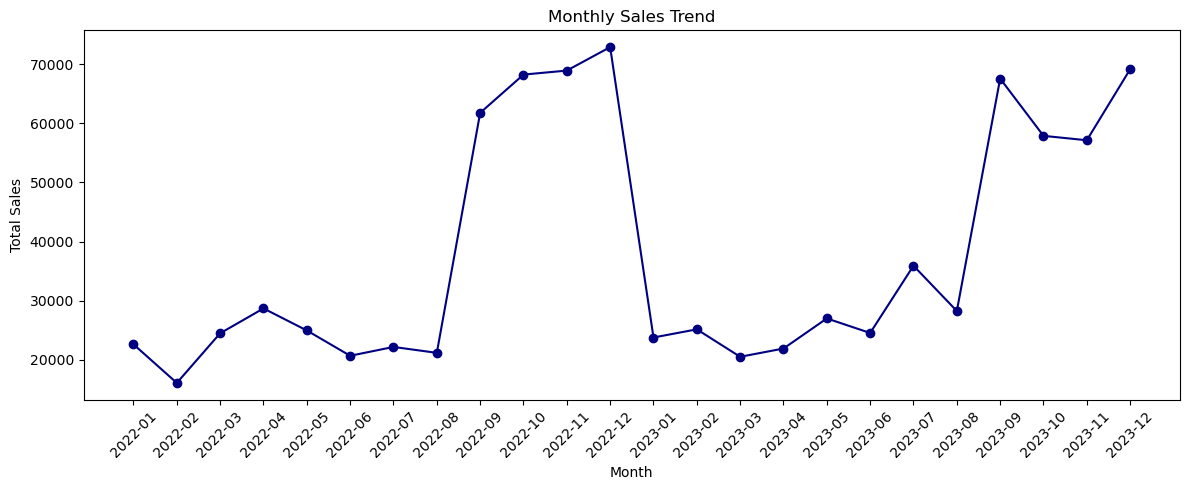

In [75]:
plt.figure(figsize=(12, 5))

plt.plot(Monthly_Sales.index.astype(str), Monthly_Sales.values, color="navy", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Observation:** Monthly sales fluctuate throughout the year, with a clear increase during the final months of both 2022 and 2023. Sales reach their highest levels during the September–December period, suggesting a recurring seasonal pattern toward the end of the year.


In [58]:
df["Quarter"]=df["Sale_date"].dt.to_period("Q")

In [59]:
Quarterly_Sales= df.groupby("Quarter")["Total_sale"].sum()
Quarterly_Sales

Quarter
2022Q1     63250.0
2022Q2     74385.0
2022Q3    105160.0
2022Q4    210030.0
2023Q1     69490.0
2023Q2     73490.0
2023Q3    131755.0
2023Q4    184160.0
Freq: Q-DEC, Name: Total_sale, dtype: float64

### 4.2 Quarterly Sales Trend

Quarterly sales are analyzed to provide a broader view of sales performance and to identify changes in demand across different quarters. This aggregation also helps highlight broader seasonal patterns that may be less apparent in monthly data.


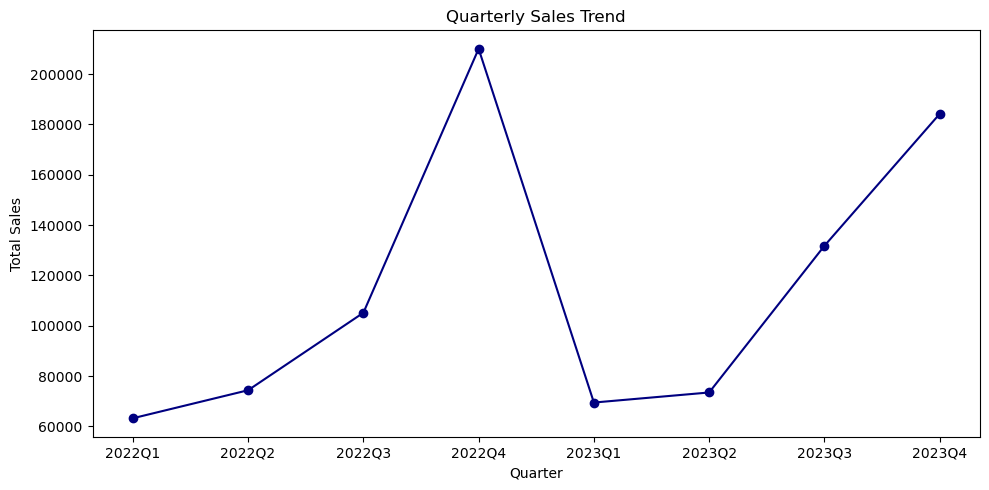

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(Quarterly_Sales.index.astype(str), Quarterly_Sales.values,color='navy', marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

**Observation:** Quarterly sales show a similar pattern to the monthly analysis, with the fourth quarter recording substantially higher sales than the earlier quarters in both years. This indicates that the increase observed in the final months is part of a broader year-end sales pattern rather than an isolated monthly spike.


## 5.1 Customer Age Group Distribution

Customer age is analyzed to understand the demographic composition of the customer base and identify the age groups that contribute most to sales transactions. Grouping customers by age also helps identify potential target segments for marketing and promotional strategies.

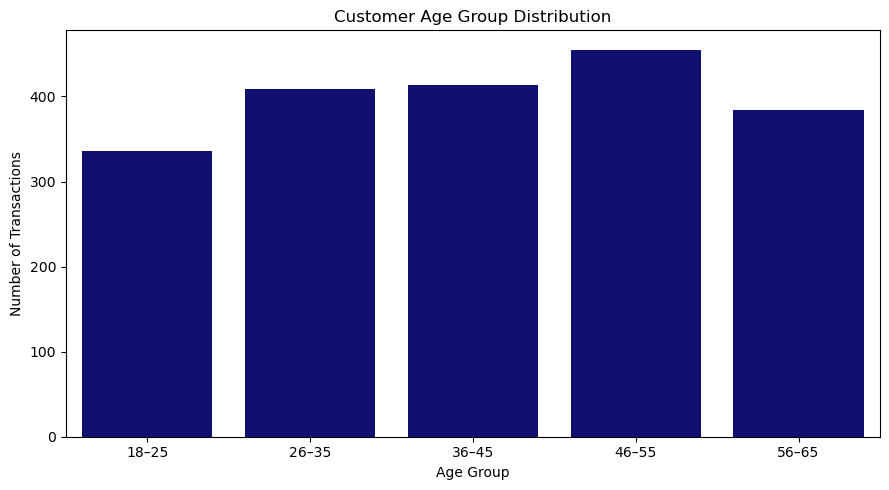

In [82]:
age_bins = [17, 25, 35, 45, 55, 65]
age_labels = ["18–25", "26–35", "36–45", "46–55", "56–65"]

df["age_group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels)

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="age_group", 
    color="navy",
    order=age_labels)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Observation

The 46–55 age group has the highest number of transactions, with approximately 450 transactions, making it the most active customer segment in the dataset. The 36–45 and 26–35 age groups follow closely, each contributing slightly above 400 transactions.

In comparison, the 18–25 group records the lowest transaction volume at approximately 335 transactions, while the 56–65 group contributes around 380 transactions.

Overall, transaction activity is concentrated among customers aged 26–55, indicating that middle-aged customers represent the core customer segment. This suggests that the business should prioritize products, promotions, and loyalty initiatives that appeal to customers in this age range, while developing targeted campaigns to increase engagement among younger customers aged 18–25.

## 5.2 Gender Distribution

Gender distribution is analyzed to understand the composition of the customer base and determine whether sales activity is concentrated within a particular gender group.

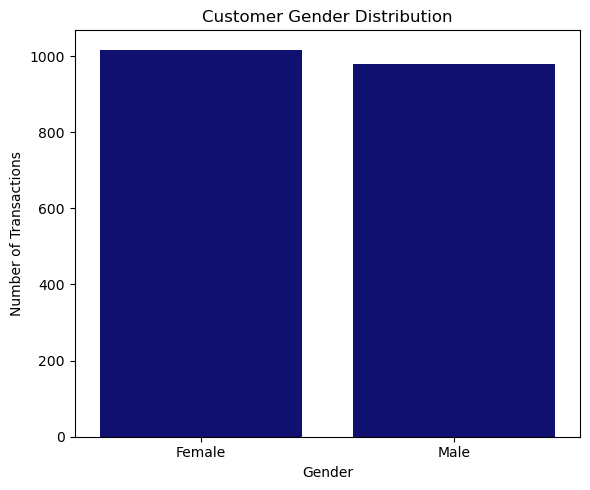

In [81]:
gender_distribution = df["Gender"].value_counts()

plt.figure(figsize=(6, 5))

sns.barplot(
    x=gender_distribution.index,
    y=gender_distribution.values, color="navy")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Observation

The distribution of transactions is relatively balanced across genders, with female customers accounting for slightly more transactions than male customers. This indicates that the business serves a broad customer base rather than relying heavily on one gender.

Marketing efforts can therefore remain broadly balanced, while more targeted strategies can be developed based on differences in product preferences and purchasing behavior across customer segments.


## 6.1 Top 10 Best-Selling Products

The top 10 best-selling products are analyzed based on the total quantity sold. This helps identify the products with the highest customer demand and provides useful insights for inventory planning and product promotion.

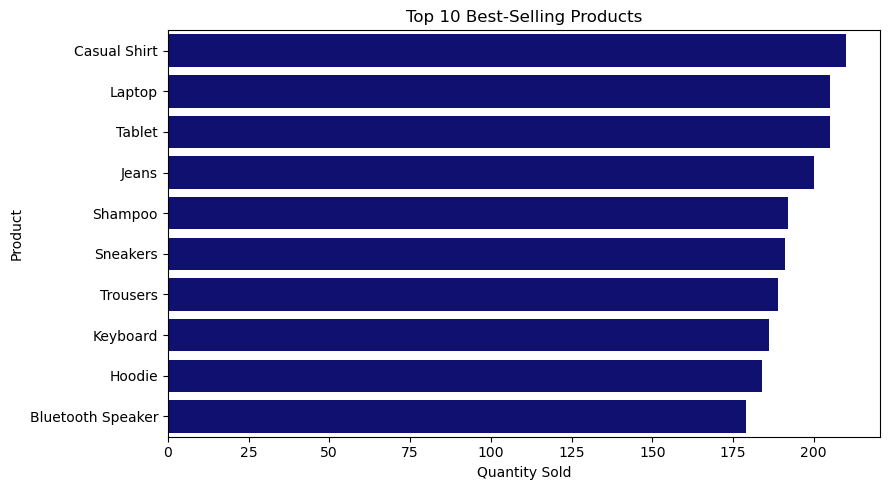

In [80]:
Top_products= (
    df.groupby("Product_name")["Quantity"].sum().sort_values(ascending= False).head(10))
plt.figure(figsize=(9,5))

sns.barplot(
    x=Top_products.values,
    y=Top_products.index, color="navy")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Observation
A notable finding is that the sales volumes across the top 10 products are relatively close. The difference between the highest-selling product, Casual Shirt, and the tenth-ranked product, Bluetooth Speaker, is only around 30 units.

This indicates that demand is relatively well distributed across the leading products rather than being concentrated in a single product. Therefore, the business should avoid relying too heavily on one best-selling product and instead maintain adequate inventory across the entire group of high-demand products.

These products also provide opportunities for cross-selling and product bundling, particularly between complementary items such as Laptops and Keyboards or Sneakers and Clothing products.


## 6.2 Revenue by Product Category

Revenue is analyzed across product categories to identify which categories contribute the most to overall sales. This comparison helps evaluate category performance and supports decisions related to inventory allocation and promotional activities.

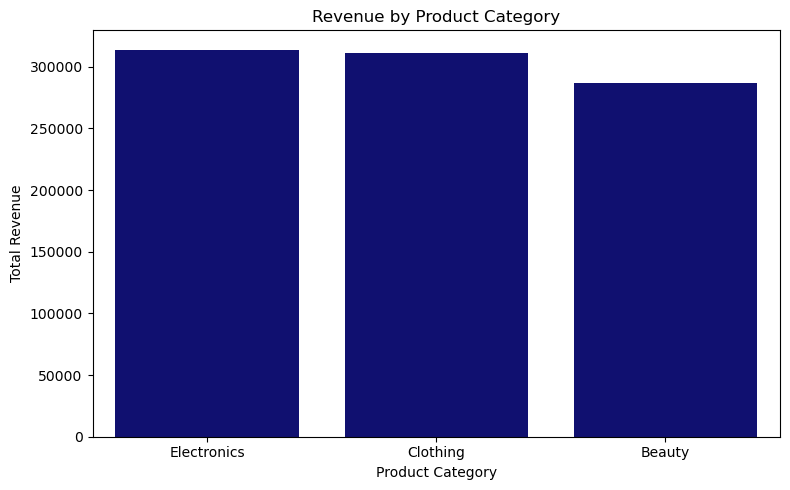

In [86]:
category_revenue = (
    df.groupby("Category")["Total_sale"].sum().sort_values(ascending=False))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values, 
    color="navy")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

### Observation

Electronics generates the highest revenue at approximately 313K, followed very closely by Clothing at around 310K. Beauty generates approximately 287K, making it the lowest-revenue category.

A key finding is that revenue is relatively evenly distributed across the three categories. Electronics and Clothing each contribute roughly one-third of total revenue, while Beauty also accounts for a substantial share despite ranking third.

This indicates that the business is not heavily dependent on a single product category. While Electronics should continue to receive strong inventory and promotional support, there is also an opportunity to increase Beauty sales, as even a moderate improvement in this category could have a meaningful impact on overall revenue.

## 7.1 Correlation Heatmap

A correlation matrix is used to examine the relationships between numerical variables in the dataset. The heatmap provides a visual representation of the strength and direction of these relationships and can help identify variables that are strongly associated with sales performance.

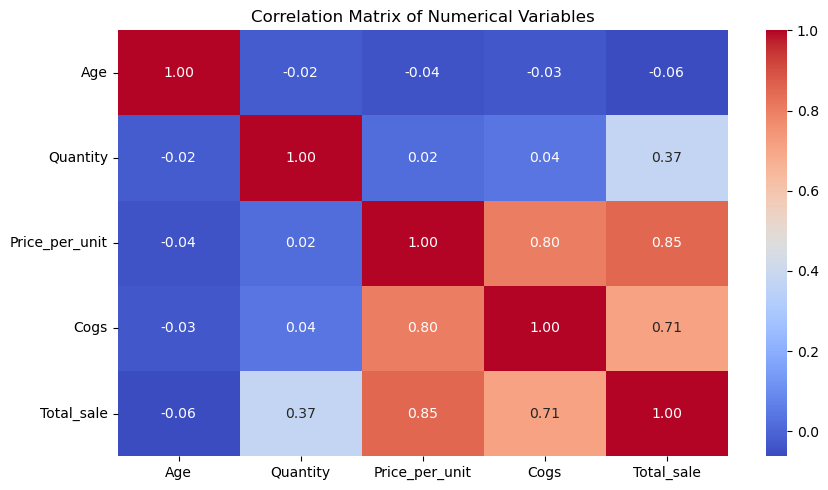

In [88]:
numeric_cols = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Observation

The strongest positive correlation is between Price per Unit and Total Sale (0.85), indicating that transactions involving higher-priced products tend to generate higher sales values. COGS also shows strong positive correlations with Price per Unit (0.80) and Total Sale (0.71), suggesting that higher-value products generally involve higher costs as well as higher revenue.

Quantity has a moderate positive correlation with Total Sale (0.37). This indicates that selling more units is associated with higher sales, but the relationship is weaker than that of price per unit. Therefore, transaction value appears to be influenced more strongly by product price than by quantity alone.

A notable finding is the near-zero correlation between Age and Total Sale (-0.06), as well as between Age and the other numerical variables. This suggests that customer age does not have a meaningful linear relationship with transaction value or purchasing quantity in this dataset.

Overall, the analysis indicates that product pricing and cost structure are more closely associated with sales performance than customer age or quantity alone. However, correlation measures association rather than causation.

## 8.1 Average Transaction Value by Age Group

Average transaction value is analyzed across customer age groups to identify whether different demographic segments have different spending patterns. This provides an additional perspective beyond simply measuring the number of transactions within each age group.

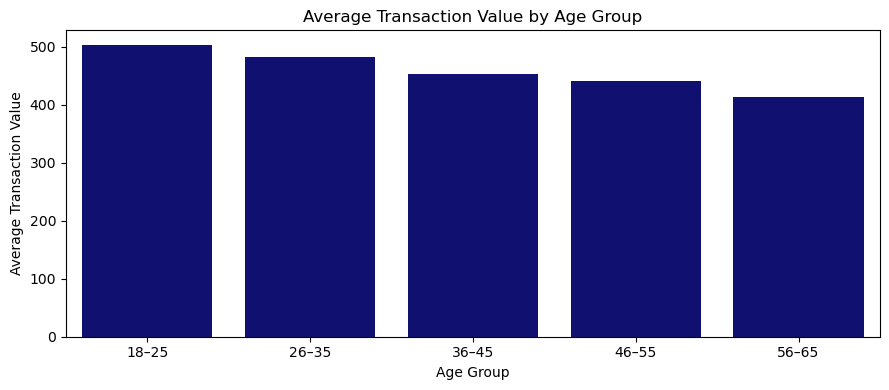

In [91]:
avg_sale_by_age = (
    df.groupby("age_group", observed=True)["Total_sale"]
      .mean()
      .reindex(age_labels))

plt.figure(figsize=(9, 4))

sns.barplot(
    x=avg_sale_by_age.index,
    y=avg_sale_by_age.values, color="navy")

plt.title("Average Transaction Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Value")
plt.tight_layout()
plt.show()

### Observation

The average transaction value shows a clear downward trend across the age groups. Customers aged 18–25 have the highest average transaction value at approximately 500, followed by the 26–35 group at around 480.

Average transaction value continues to decline among older groups, reaching approximately 450 for customers aged 36–45, 440 for those aged 46–55, and around 415 for customers aged 56–65.

This indicates that younger customers generate higher-value transactions on average, despite the 18–25 age group having the lowest transaction volume. This is an important finding because transaction volume alone does not represent customer value.

The business could therefore focus on increasing engagement and retention among younger customers, as they demonstrate higher spending per transaction, while targeted offers could be used to encourage higher spending among older customer segments.

# 9. Conclusion & Business Recommendations

## Conclusion

The exploratory data analysis revealed clear patterns in seasonal sales performance, customer purchasing behavior, and product demand. The findings show that sales performance is influenced by recurring year-end demand, differences in customer spending behavior across age groups, and a diversified product and category portfolio.

Overall, the analysis highlights opportunities to improve business performance through better seasonal planning, targeted customer strategies, effective inventory management, and data-driven pricing decisions.


## Business Recommendations
1. Prepare for the year-end sales peak

Sales increase significantly between September and December, with the fourth quarter consistently outperforming the earlier quarters. The business should use this pattern to plan inventory levels, staffing, and promotional campaigns in advance of the year-end period. Preparing early can help prevent stockouts during high-demand months and allow the business to maximize revenue during its strongest sales period.

2. Focus on increasing engagement among younger high-spending customers

Customers aged 18–25 generate the highest average transaction value despite recording the lowest transaction volume. This represents a potential growth opportunity. The business should investigate ways to increase the purchase frequency of this segment through targeted digital campaigns, personalized promotions, and loyalty incentives while maintaining their relatively high spending per transaction.

3. Retain and strengthen engagement with the core customer base

Customers aged 26–55 account for the largest share of transactions, making them the business's most active customer segment. The business should maintain strong engagement with these customers through relevant promotions, loyalty programs, and product offerings designed around their purchasing behavior. Retaining this core segment is important because of its consistent contribution to overall transaction activity.

4. Manage inventory across multiple high-demand products

Sales volume among the top 10 products is relatively close, indicating that demand is not concentrated in a single best-selling product. Inventory planning should therefore focus on maintaining availability across a broader portfolio of high-demand products rather than prioritizing only the top-ranked item. Complementary products can also be used in bundles and cross-selling strategies to increase transaction value.

5. Maintain a diversified category strategy

Although Electronics generates the highest revenue, the difference between the three product categories is relatively small. This indicates that the business is not heavily dependent on one category, which reduces concentration risk. The business should continue supporting all major categories while identifying targeted opportunities to improve the performance of lower-revenue categories, particularly Beauty.

6. Use pricing strategically to increase transaction value

Price per Unit has the strongest positive relationship with Total Sale, suggesting that transaction value is more closely associated with product price than with quantity alone. The business should further analyze pricing opportunities, premium product offerings, and product mix strategies. However, pricing decisions should also consider customer demand and profitability rather than relying on correlation alone.